# Lab 4.06 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6 - Influence of background music on purchasing behaviour

Market research shows that background music in a supermarket can influence the purchasing behaviour of customers. A study compared three methods: no music, French chansons and Italian hits. In each case, the number of bottles of French, Italian and other wines sold was counted (Ryan, et al., 1998).

The research data can be found in the file data/MuziekWijn.csv.

1. Set up the correct crosstab.
2. Determine the marginal totals.
3. Determine the expected results.
4. Calculate the χ² test statistic.
5. Calculate Cramér's V. What can you conclude from this?

Visualize the data set:

1. Plot a bar chart showing the percentages of types of wine sold when no music was playing.
2. Plot a clustered bar chart of the dataset
3. Plot a bar chart (stacked bar chart) of the dataset

Results of the main calculations (rounded up to 3 decimal places):

* χ² ≈ 18.279
* Cramér's V ≈ 0.194

In [2]:
musicwine = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-en-labs/main/data/MuziekWijn.csv')
musicwine.info()
musicwine.Muziek = musicwine.Muziek.astype('category')
musicwine[' Wijn'] = musicwine[' Wijn'].astype('category')

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Muziek  243 non-null    str  
 1    Wijn   243 non-null    str  
dtypes: str(2)
memory usage: 3.9 KB


Read the dataset

In [3]:
musicwine.head()

,Muziek,Wijn
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse


Give the names of both columns. What is wrong?

In [4]:
musicwine.dtypes

Muziek    category
 Wijn     category
dtype: object

You can change the name of a column 'ab' to the column 'abc' of the dataframe df, using the following command

`df = df.rename(columns={'ab': 'abc'})`

Use this command to change the column name.  
Check afterwards if the result is correct.

In [5]:
musicwine = musicwine.rename(columns={'Muziek': 'Music'})
musicwine = musicwine.rename(columns={' Wijn': 'Wine'})
musicwine.head()

,Music,Wine
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse


1. Set up the correct crosstab.

In [6]:
pd.crosstab(musicwine.Music, musicwine.Wine, margins=True)

Wine,Andere,Franse,Italiaanse,All
Music,,,,
Franse,35,39,1,75
Geen,43,30,11,84
Italiaanse,35,30,19,84
All,113,99,31,243


2. Determine the marginal totals.

In [7]:
observed = pd.crosstab(musicwine.Music, musicwine.Wine)
row_sums = observed.sum(axis=1)
col_sums = observed.sum()
n = row_sums.sum()

print(row_sums)
print(col_sums)
print(f'Number of observations: {n}')

Music
Franse        75
Geen          84
Italiaanse    84
dtype: int64
Wine
Andere        113
Franse         99
Italiaanse     31
dtype: int64
Number of observations: 243


3. Determine the expected results.

In [8]:

expected = np.outer(row_sums, col_sums) / n
print(expected)

[[34.87654321 30.55555556  9.56790123]
 [39.0617284  34.22222222 10.71604938]
 [39.0617284  34.22222222 10.71604938]]


4. Calculate the χ² test statistic.

In [9]:
diffs = (expected - observed)**2 / expected
print(diffs)

Wine          Andere    Franse  Italiaanse
Music                                     
Franse      0.000437  2.333737    7.672417
Geen        0.397063  0.520924    0.007524
Italiaanse  0.422348  0.520924    6.403837


In [10]:
chi_squared = diffs.values.sum()
print('χ² ≈ %.3f' %chi_squared)

χ² ≈ 18.279


5. Calculate Cramér's V. What can you conclude from this?

In [14]:
dof = min(observed.shape) - 1
cramers_v = np.sqrt(chi_squared / (dof * n))
print(cramers_v)

0.19393696480652944


Plot a bar chart showing the percentages of types of wine sold when no music was playing.

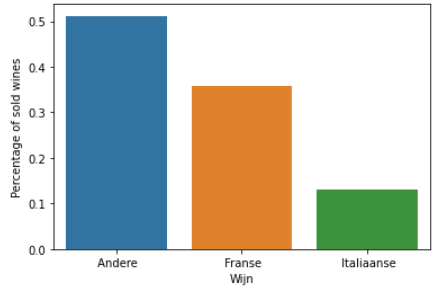

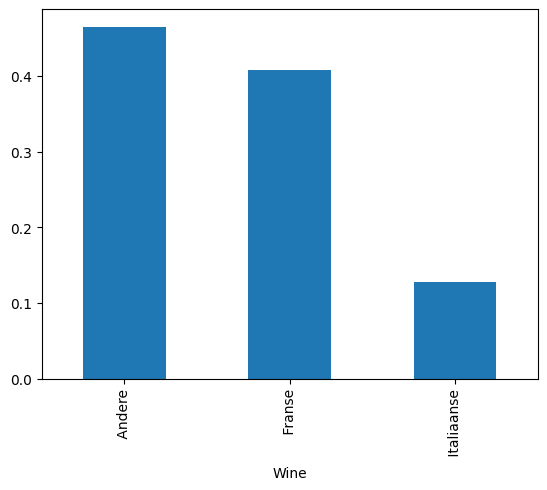

In [26]:
percentages = musicwine['Wine'].value_counts(normalize=True)

# Plot
percentages.plot(kind='bar')
plt.show()

Plot a clustered bar chart of the dataset  

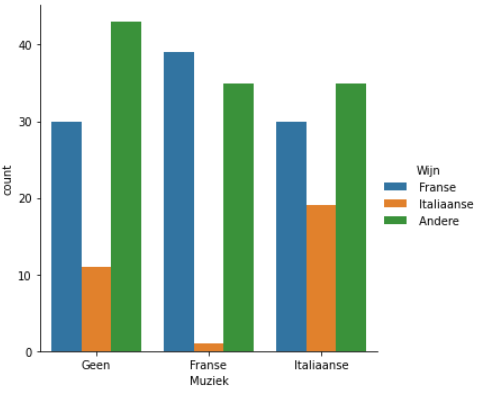

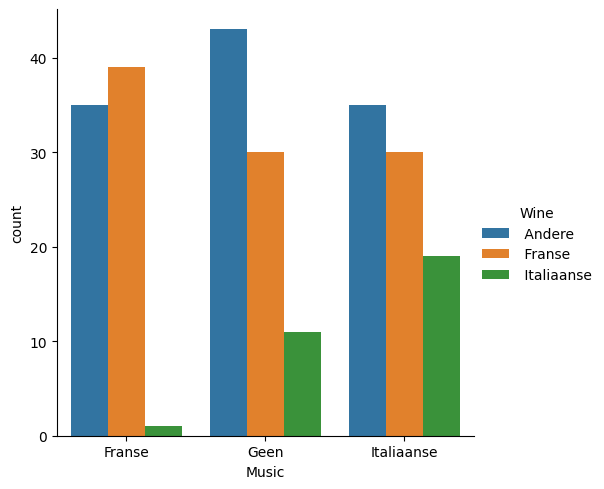

In [17]:
sns.catplot(data=musicwine, x='Music', hue='Wine', kind='count');

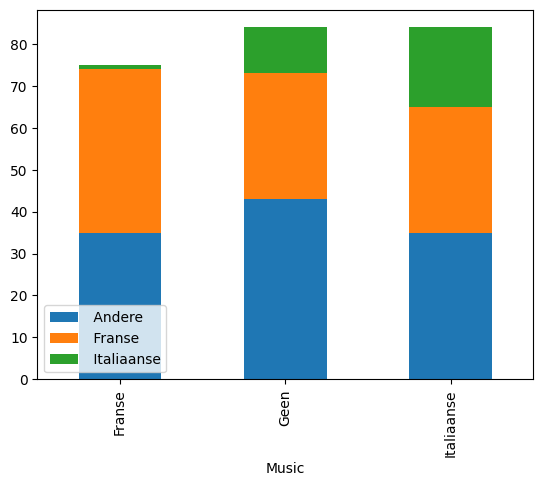

In [34]:
# Contingency table without the margins
observed = pd.crosstab(musicwine.Music, musicwine.Wine)

# Horizontally oriented stacked bar chart
observed.plot(kind='bar', stacked=True).legend(loc='lower left')

Plot a bar chart (stacked bar chart) of the dataset

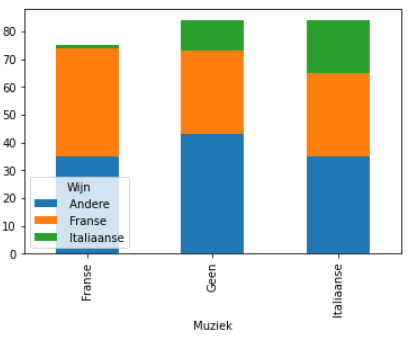